In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [114]:
## reading the dataset
df = pd.read_csv('height-weight02.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Weight')

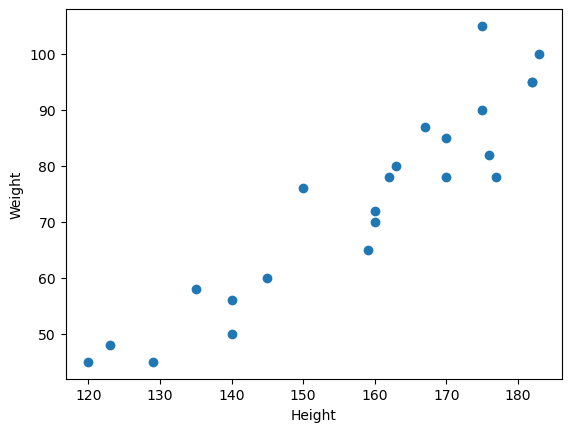

In [115]:
plt.scatter(df['Height'], df['Weight'])
plt.xlabel('Height')
plt.ylabel('Weight')

In [116]:
X = df[['Weight']]  # independent feature
y = df['Height']   # dependent feature


In [117]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# this means X_train & y_train are to be used for model training and X_test & y_test for testing pupose
# test_size means 80% of dataframes will be used for training & remaining 20% for testing

In [118]:
X.shape

(23, 1)

In [119]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((18, 1), (5, 1), (18,), (5,))

In [120]:
# we standardise the dataset -- only the independent feature
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [121]:
X_train = scaler.fit_transform(X_train)
#### you need to remember for the - trainingData we need to do .fit_transform() & for - testData we need to .transform() to prevent data-leakage ###
## This is to prevent my model from knowing about the test data 
# here fit_tansform calculates the mean and standard deviation of X_train 
# we need Z-score and apply it on every record of 
X_test = scaler.transform(X_test)

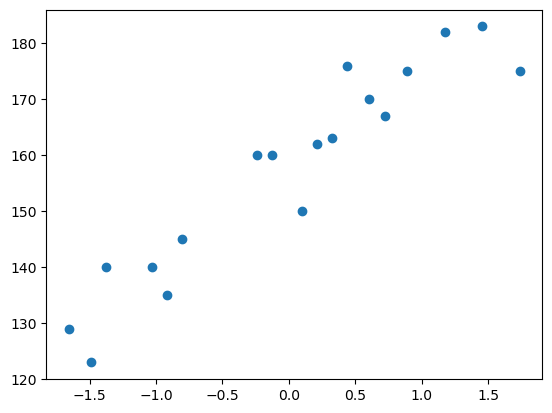

In [122]:
plt.scatter(X_train, y_train)

In [123]:
## Now we need to train our model - Simple Linear Regression - simple because here I have only one feature
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()

In [124]:
regressor.fit(X_train, y_train)  # trained the model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [125]:
print("The slope or coefficient of weight", regressor.coef_)  # this is 'theta1'
print("The intercept: ", regressor.intercept_)     ## this is 'theta0'

# now I will get my h-theta(x)  ---> my best fit line

The slope or coefficient of weight [17.03440872]
The intercept:  157.5


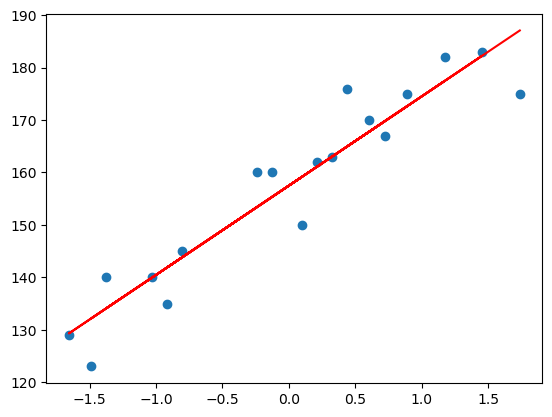

In [126]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regressor.predict(X_train), color='red')

Prediction of train data ( done above)
1. predicted height output = intercept + coef(Weights)
2. y_pred_train = 157.5 + 17.03(X_test)

Prediction of test data 
1. predicted height output = intercept + coef(Weights)
2. y_pred_test = 157.5 + 17.03(X_test)

In [127]:
y_pred_test = regressor.predict(X_test)
y_pred_test, y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

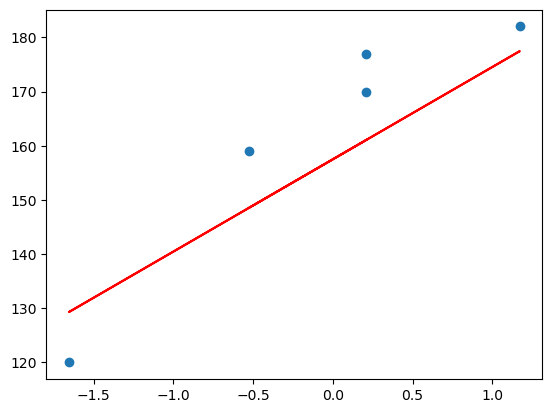

In [128]:
plt.scatter(X_test, y_test)
plt.plot(X_test, regressor.predict(X_test), color='red')

 Performnce Metrics
 we'll be focused on calculating - MSE, MAE, NMSE, Rsquare & adjusted R square

In [132]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test, y_pred_test)
mae =  mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

109.77592599051664
9.822657814519232
10.477400726827081


In [133]:
from sklearn.metrics import r2_score
## R-Squared
score = r2_score(y_test, y_pred_test)
print(score)


0.776986986042344


In [134]:

# r-squared value is always > than adjusted r-squared
# display adjusted R-squared
1- (1-score)*(len(y_test)-1)/(len(y_test) - X_test.shape[1]-1)

0.7026493147231252

In [136]:
#let' say I am getting a new datapoint --> 80
#I'll write:

scaled_weight = scaler.transform([[80]])
scaled_weight

D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [137]:
regressor.predict([scaled_weight[0]])
## here also we have to give a 2-dimensional value, since earlier we gave 2-d value during transform
# below (163.01) is the predicted value for weight - 80 kg

array([163.01076266])

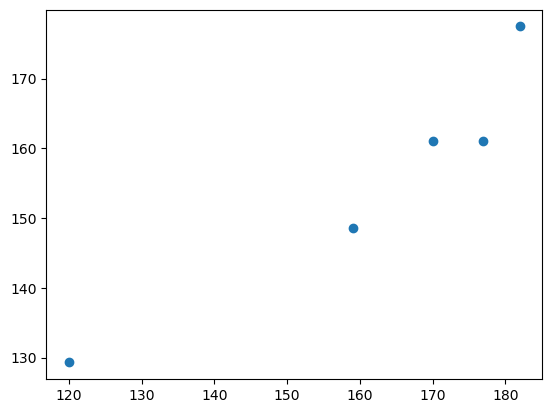

In [138]:
## ASSUMPTIONS
# plot a scatter plot for prediction
plt.scatter( y_test,y_pred_test)

In [139]:
# it is linearly distributed --> which shows you have actually done a good prediction

In [141]:
# residuals - difference btwn y_test & y_pred_test
residuals = y_test - y_pred_test
residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

In [142]:
# plot the residuals 

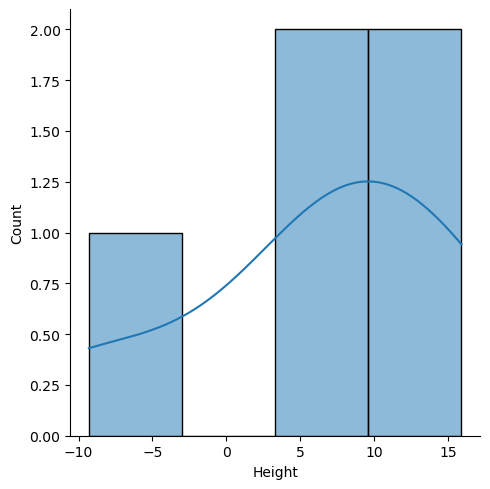

In [143]:
sns.displot(residuals, kde= True)

In [ ]:
# pickling  the model